In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('telco_customer_churn.csv')
pd.set_option('display.max_columns',None)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
print(f"No of rows = {df.shape[0]}")
print(f"No of columns = {df.shape[1]}")

No of rows = 7043
No of columns = 21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [136]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [138]:
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)

In [139]:
df['TotalCharges']=df['TotalCharges'].astype('float')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
print(f'No of duplicate values = {df.duplicated().sum()}')

No of duplicate values = 0


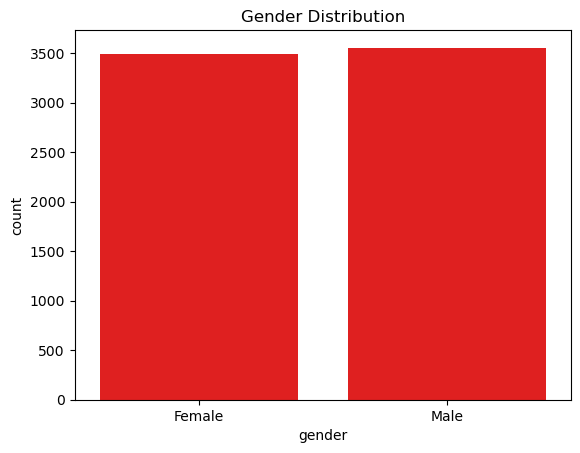

In [9]:
plt.title('Gender Distribution')
sns.countplot(data=df,x='gender',color='red')
plt.show()

In [10]:
print(f"Male Percentage = {(((df['gender']=='Male').sum()*100)/len(df)).round(2)}%")
print(f"Female Percentage = {(((df['gender']=='Female').sum()*100)/len(df)).round(2)}%")

Male Percentage = 50.48%
Female Percentage = 49.52%


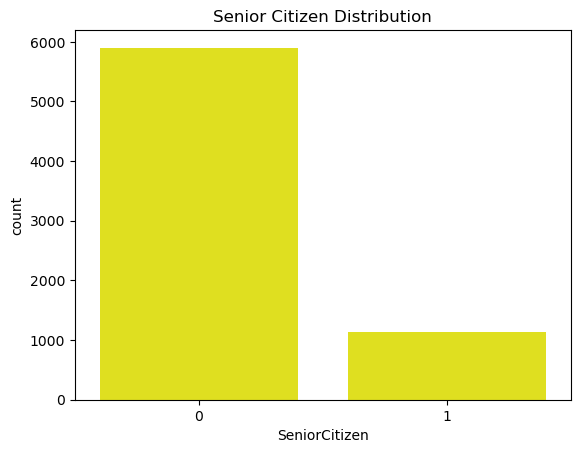

In [11]:
plt.title('Senior Citizen Distribution')
sns.countplot(data=df,x='SeniorCitizen',color='yellow')
plt.show()

In [12]:
print(f'Percentage of Senior Citizens = {((df['SeniorCitizen']==1).sum()*100)/len(df):.2f}%')

Percentage of Senior Citizens = 16.21%


In [13]:
print(f'Percentage of Customer having a partner  = {((df['Partner']=='Yes').sum()*100)/len(df):.2f}%')

Percentage of Customer having a partner  = 48.30%


In [14]:
print(f'Percentage of Dependent Customers= {((df['Dependents']=='Yes').sum()*100)/len(df):.2f}%')

Percentage of Dependent Customers= 29.96%


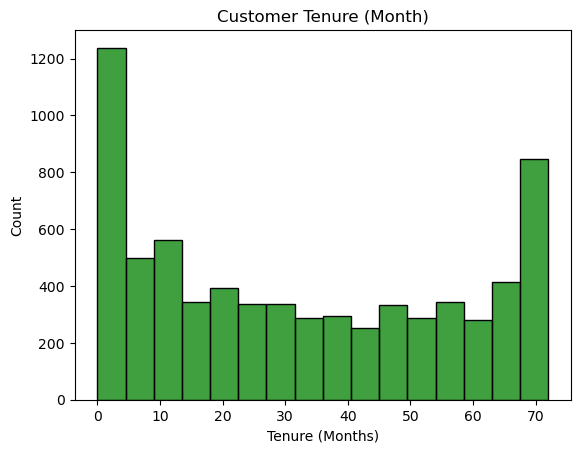

In [15]:
sns.histplot(data=df,x='tenure',color='green')
plt.title('Customer Tenure (Month)')
plt.xlabel('Tenure (Months)')
plt.show()

In [16]:
print(f'Approximately {((df['tenure']>=24).sum()*100)/len(df):.2f}% of customers have a tenure of at least 1 year (24 months)')
print(f'The Longest Customer tenure is of {df['tenure'].max()} months')

Approximately 55.76% of customers have a tenure of at least 1 year (24 months)
The Longest Customer tenure is of 72 months


In [17]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

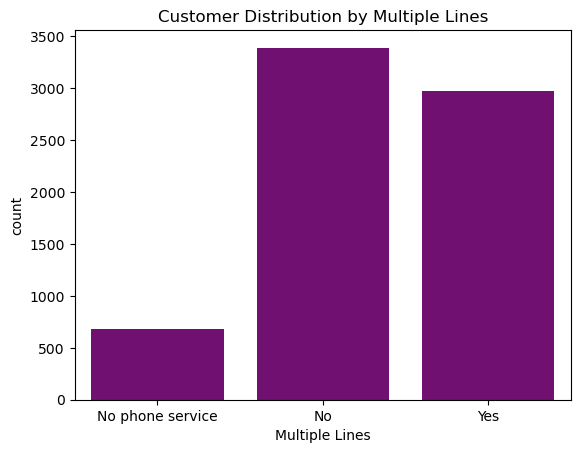

In [18]:
sns.countplot(data=df,x='MultipleLines',color='purple')
plt.xlabel('Multiple Lines')
plt.title('Customer Distribution by Multiple Lines')
plt.show()

In [19]:
print(f"{((df['MultipleLines']=='No phone service').sum()*100)/len(df):.2f}% Customer having No Phone service")
print(f"{((df['MultipleLines']=='No').sum()*100)/len(df):.2f}% Customer having only one phone line")
print(f"{((df['MultipleLines']=='Yes').sum()*100)/len(df):.2f}% Customer having Multiple phone line")

9.68% Customer having No Phone service
48.13% Customer having only one phone line
42.18% Customer having Multiple phone line


In [20]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

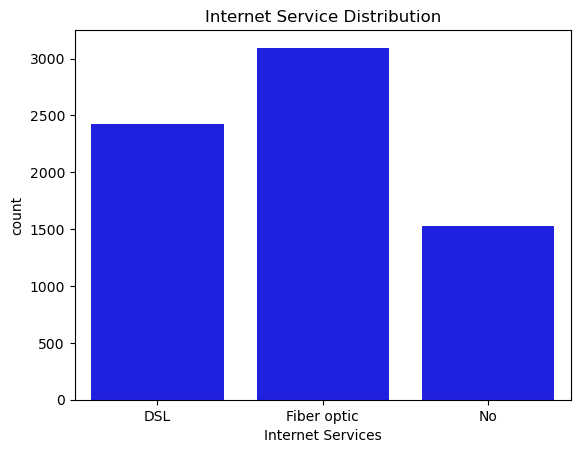

In [21]:
sns.countplot(data=df,x='InternetService',color='Blue')
plt.title('Internet Service Distribution')
plt.xlabel('Internet Services')
plt.show()

In [35]:
print(f'{((df['InternetService']=='No').sum()*100)/len(df):.2f}% of customers has No Intenet Service')
print(f'{((df['InternetService']!='No').sum()*100)/len(df):.2f}% of customer uses Intenet Service')
print(f"{((df['OnlineSecurity']=='Yes').sum()*100)/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to Online Security")

21.67% of customers has No Intenet Service
78.33% of customer uses Intenet Service
36.60% of customers with Internet service have subscribed to Online Security


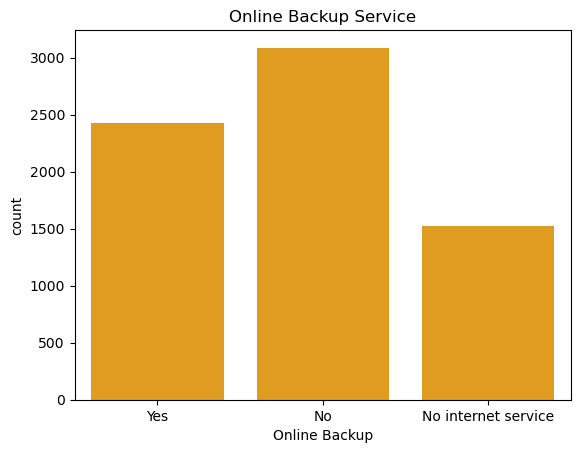

In [39]:
sns.countplot(data=df,x='OnlineBackup',color='orange')
plt.title('Online Backup Service')
plt.xlabel('Online Backup')
plt.show()

In [68]:
print(f"{(df['OnlineBackup']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have Online backup Service")
print(f"Among customers with internet service, {(df['DeviceProtection']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% have opted for the Device Protection Service.")
print(f"{(df['TechSupport']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the Tech Support service.")
print(f"{(df['StreamingTV']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the company's TV streaming service.")
print(f"{(df['StreamingMovies']=='Yes').sum()*100/(df['InternetService']!='No').sum():.2f}% of customers with Internet service have subscribed to the company's movie streaming service.")

44.03% of customers with Internet service have Online backup Service
Among customers with internet service, 43.90% have opted for the Device Protection Service.
37.05% of customers with Internet service have subscribed to the Tech Support service.
49.07% of customers with Internet service have subscribed to the company's TV streaming service.
49.52% of customers with Internet service have subscribed to the company's movie streaming service.


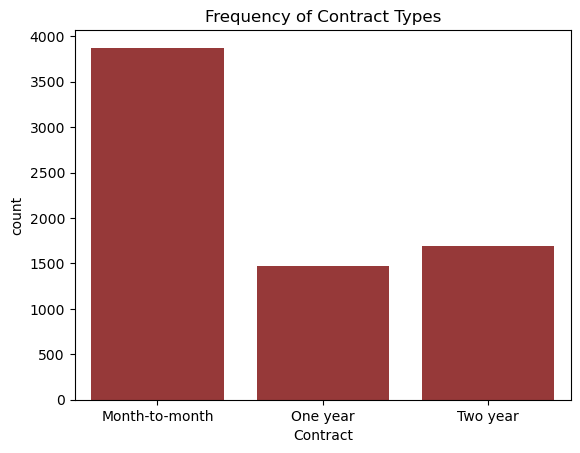

In [75]:
sns.countplot(data=df,x='Contract',color='brown')
plt.title('Frequency of Contract Types')
plt.show()

In [87]:
print(f'{(df['PaperlessBilling']=='Yes').sum()*100/len(df):.2f}% of customers were using Paper less billing')

59.22% of customers were using Paper less billing


In [88]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [109]:
print(f"Most Customer uses the '{df['PaymentMethod'].value_counts().idxmax()}' as their Payment Method")

Most Customer uses the 'Electronic check' as their Payment Method


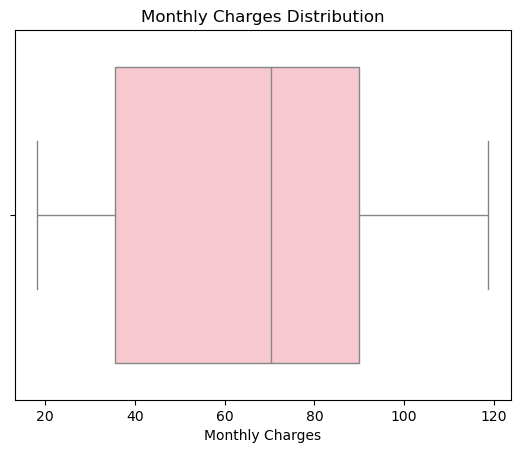

In [121]:
sns.boxplot(data=df,x='MonthlyCharges',color='pink')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.show()

In [127]:
print(f"The average monthly charge per customer is {df['MonthlyCharges'].mean():.2f}")

The average monthly charge per customer is 64.76


In [140]:
print(f"The average total charge per customer is {df['TotalCharges'].mean():.2f}.")

The average total charge per customer is 2283.30.
